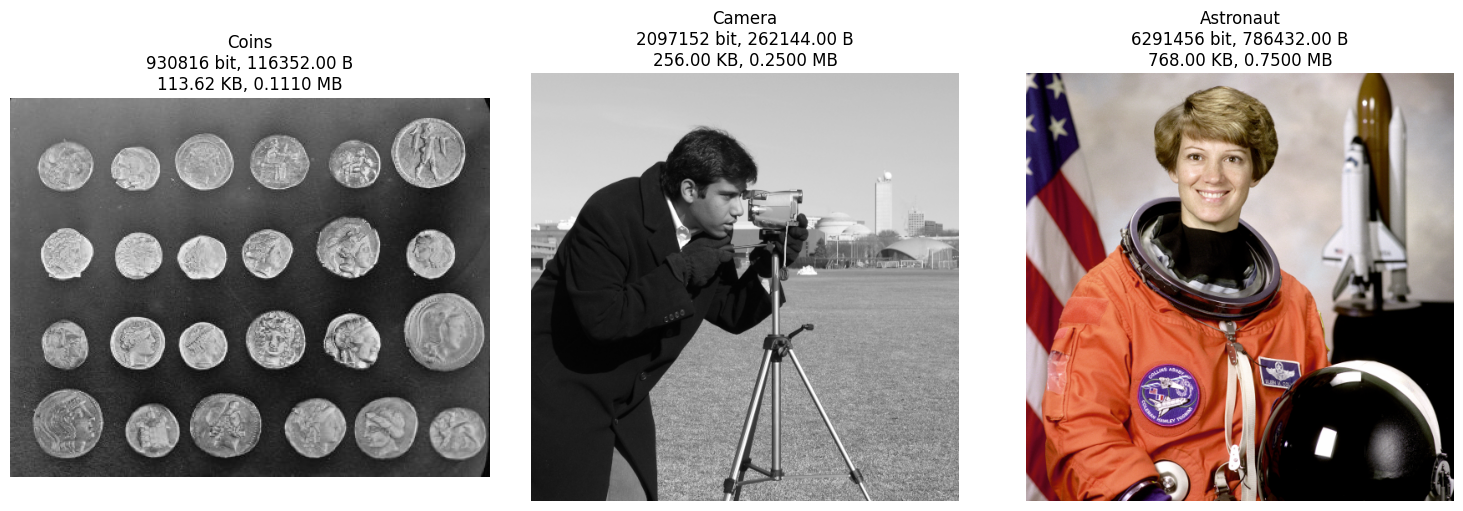

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data

# Contoh gambar dari scikit-image
gambar_coins = data.coins()
gambar_camera = data.camera()
gambar_astronaut = data.astronaut()

# Fungsi untuk menghitung ukuran gambar dalam bit, byte, KB, MB
def hitung_ukuran(image):
    bit_per_pixel = 8 if len(image.shape) == 2 else 24 # Grayscale = 8 bit, RGB = 24 bit
    total_pixels = image.shape[0] * image.shape[1]
    total_bits = total_pixels * bit_per_pixel
    total_bytes = total_bits / 8
    total_kb = total_bytes / 1024
    total_mb = total_kb / 1024
    return total_bits, total_bytes, total_kb, total_mb

# Menyusun gambar dan ukurannya dalam satu baris
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Daftar gambar dan nama
gambar_list = [gambar_coins, gambar_camera, gambar_astronaut]
nama_list = ["Coins", "Camera", "Astronaut"]

for ax, img, nama in zip(axes, gambar_list, nama_list):
    bits, bytes_, kb, mb = hitung_ukuran(img)
    ax.imshow(img, cmap='gray' if len(img.shape) == 2 else None)
    ax.set_title(f"{nama}\n{bits} bit, {bytes_:.2f} B\n{kb:.2f} KB, {mb:.4f} MB")
    ax.axis('off')

plt.tight_layout()
plt.show()

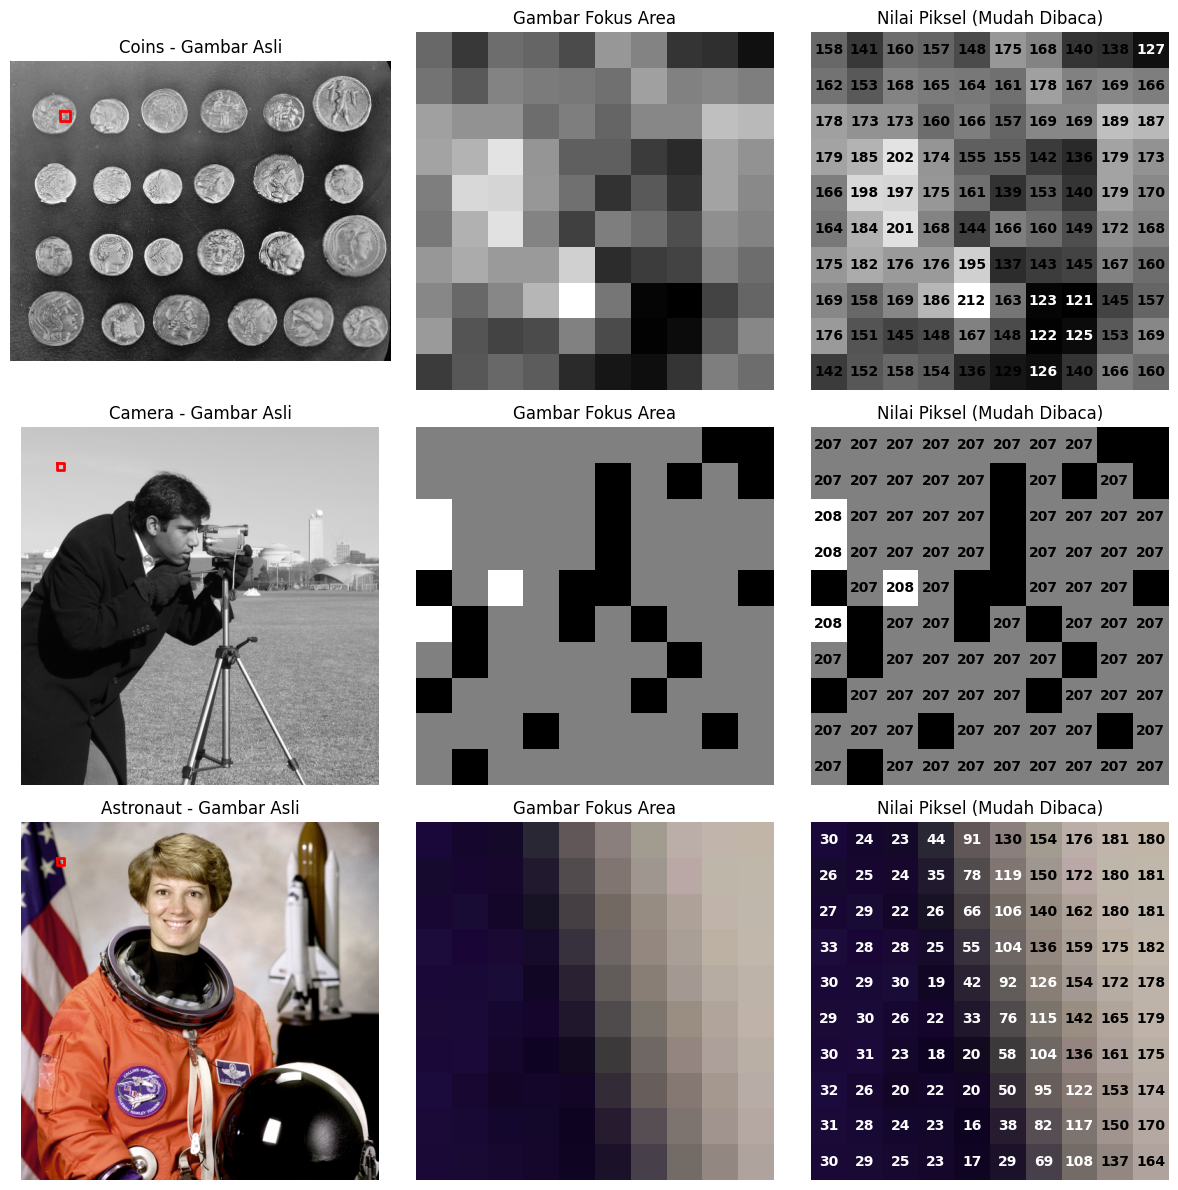

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 01: Menampilkan bagaimana citra digital tersusun dari piksel dengan area fokus yang ditandai
# 02: Praktikum Pengolahan Citra Ir. Prayitno, S.ST., M.T., Ph.D.

fig, axes = plt.subplots(3, 3, figsize=(12, 12))

# 05: List gambar dan nama
gambar_list = [gambar_coins, gambar_camera, gambar_astronaut]
nama_list = ["Coins", "Camera", "Astronaut"]

# 09: Koordinat area kecil yang di-zoom (10x10 piksel)
x_start, x_end = 50, 60
y_start, y_end = 50, 60

for i, (img, nama) in enumerate(zip(gambar_list, nama_list)):

    # --- KOLOM 1: GAMBAR ASLI ---
    axes[i, 0].imshow(img, cmap='gray' if len(img.shape) == 2 else None)
    axes[i, 0].set_title(f"{nama} - Gambar Asli")
    axes[i, 0].axis('off')

    # 19: Tambahkan kotak merah untuk menunjukkan area yang difokuskan
    rect_x = [x_start, x_end, x_end, x_start, x_start]
    rect_y = [y_start, y_start, y_end, y_end, y_start]
    axes[i, 0].plot(rect_x, rect_y, color="red", linewidth=2)

    # --- KOLOM 2: GAMBAR FOKUS AREA (ZOOM) ---
    zoomed_img = img[y_start:y_end, x_start:x_end]
    axes[i, 1].imshow(zoomed_img, cmap='gray' if len(img.shape) == 2 else None, interpolation='nearest')
    axes[i, 1].set_title("Gambar Fokus Area")
    axes[i, 1].axis('off')

    # --- KOLOM 3: NILAI PIKSEL ---
    # 30: Menampilkan nilai piksel dalam area yang di-zoom
    axes[i, 2].imshow(zoomed_img, cmap='gray' if len(img.shape) == 2 else None, interpolation='nearest')

    for y in range(zoomed_img.shape[0]):
        for x in range(zoomed_img.shape[1]):
            # 35: Jika RGB, ambil nilai rata-rata piksel untuk tampilan angka tunggal
            if len(img.shape) == 3:
                pixel_value = np.mean(zoomed_img[y, x]).astype(int)
            else:
                pixel_value = zoomed_img[y, x]

            # 40: Pilih warna teks kontras (putih untuk gelap, hitam untuk terang)
            text_color = "white" if pixel_value < 128 else "black"
            axes[i, 2].text(x, y, str(pixel_value), color=text_color,
                             ha='center', va='center', fontsize=10, fontweight='bold')

    axes[i, 2].set_title("Nilai Piksel (Mudah Dibaca)")
    axes[i, 2].axis('off')

plt.tight_layout()
plt.show()


 ANALISIS CITRA: Coins 
Tipe Objek      : <class 'numpy.ndarray'>
Dimensi (Shape) : (303, 384)
Tipe Data Piksel: uint8

Slice Matriks (5x5 pertama):
[[ 47 123 133 129 137]
 [ 93 144 145 143 145]
 [126 147 143 147 145]
 [131 136 133 139 136]
 [131 133 134 135 129]]

 ANALISIS CITRA: Camera 
Tipe Objek      : <class 'numpy.ndarray'>
Dimensi (Shape) : (512, 512)
Tipe Data Piksel: uint8

Slice Matriks (5x5 pertama):
[[200 200 200 200 199]
 [200 199 199 200 199]
 [199 199 199 200 200]
 [200 200 199 199 199]
 [200 200 200 200 199]]

 ANALISIS CITRA: Astronaut 
Tipe Objek      : <class 'numpy.ndarray'>
Dimensi (Shape) : (512, 512, 3)
Tipe Data Piksel: uint8

Slice Matriks (5x5 pertama):
[[154 109  63  54  76]
 [177 144 113 106 128]
 [201 182 168 159 167]
 [220 214 202 197 200]
 [232 226 221 215 221]]


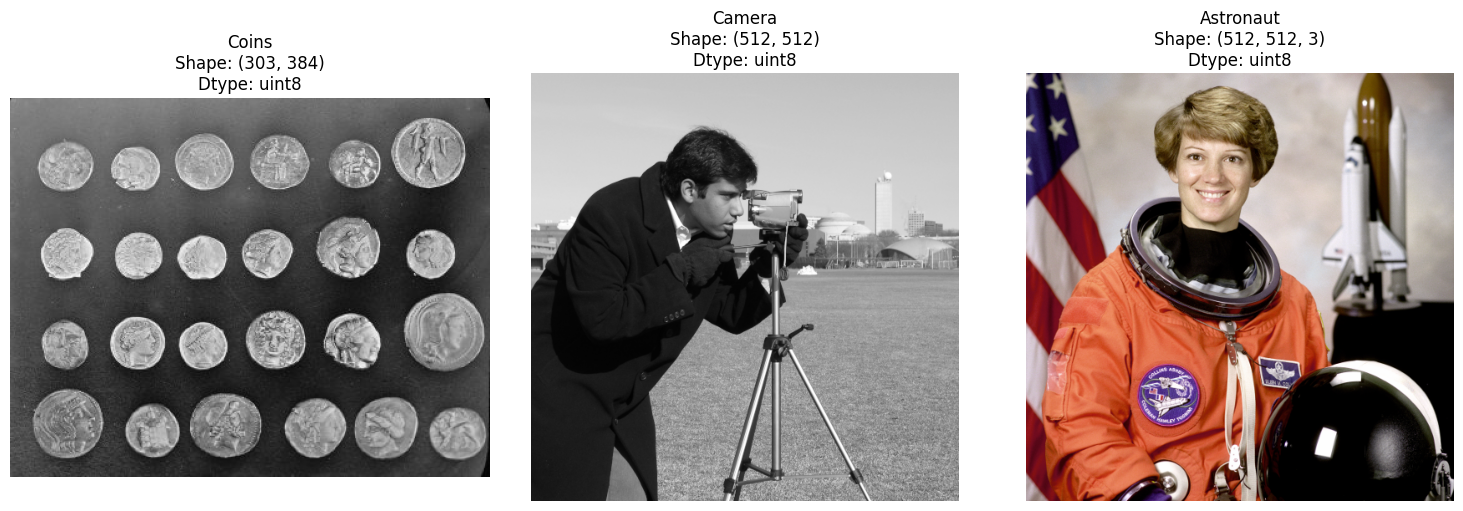

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data

# 1. Load Dataset
gambar_coins = data.coins()
gambar_camera = data.camera()
gambar_astronaut = data.astronaut()

# 2. Fungsi Bedah Struktur Array
def info_array_numpy(image, nama):
    print(f"\n" + "="*30)
    print(f" ANALISIS CITRA: {nama} ")
    print(f"="*30)

    # Menunjukkan bahwa gambar adalah objek NumPy
    print(f"Tipe Objek      : {type(image)}")

    # Menunjukkan dimensi (H, W) atau (H, W, C)
    print(f"Dimensi (Shape) : {image.shape}")

    # Menunjukkan tipe data (biasanya uint8)
    print(f"Tipe Data Piksel: {image.dtype}")

    # Menampilkan 'jeroan' gambar dalam bentuk angka
    print("\nSlice Matriks (5x5 pertama):")
    if len(image.shape) == 2:
        # Untuk Grayscale (2D)
        print(image[:5, :5])
    else:
        # Untuk RGB (3D), kita ambil channel merahnya saja agar tidak pusing
        print(image[:5, :5, 0])

# 3. Eksekusi Analisis di Terminal
info_array_numpy(gambar_coins, "Coins")
info_array_numpy(gambar_camera, "Camera")
info_array_numpy(gambar_astronaut, "Astronaut")

# 4. Visualisasi Pendukung
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
gambar_list = [gambar_coins, gambar_camera, gambar_astronaut]
nama_list = ["Coins", "Camera", "Astronaut"]

for ax, img, nama in zip(axes, gambar_list, nama_list):
    ax.imshow(img, cmap='gray' if len(img.shape) == 2 else None)
    ax.set_title(f"{nama}\nShape: {img.shape}\nDtype: {img.dtype}")
    ax.axis('off')

plt.tight_layout()
plt.show()

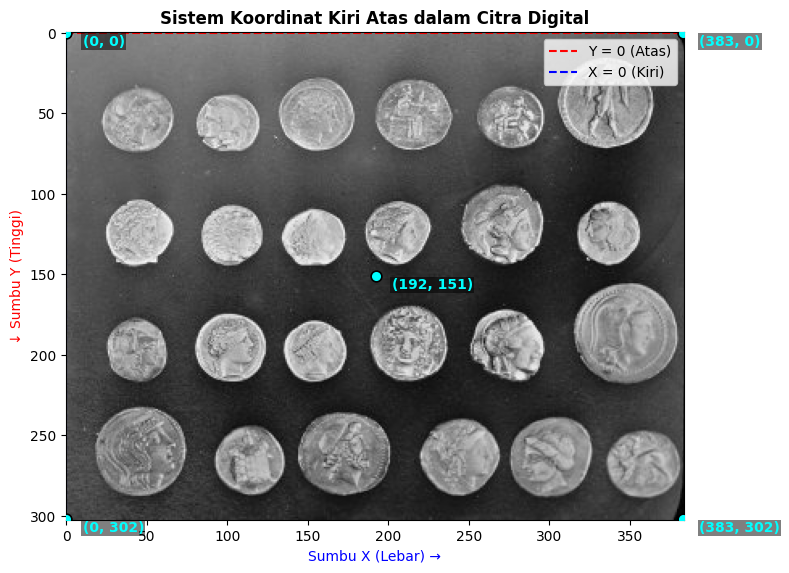

In [ ]:
import matplotlib.pyplot as plt
from skimage import data

# 01: Menjelaskan sistem koordinat kiri atas dalam citra digital
# 14: Praktikum Pengolahan Citra Ir. Prayitno, S.ST., M.T., Ph.D.

# --- PERSIAPAN DATA ---
# 04: Pilih salah satu gambar untuk contoh koordinat
gambar_sample = data.coins()
height, width = gambar_sample.shape

# --- INISIALISASI PLOT ---
fig, ax = plt.subplots(figsize=(8, 8))

# 12: Tampilkan gambar
ax.imshow(gambar_sample, cmap='gray')

# 15: Tambahkan anotasi sumbu koordinat
ax.set_title("Sistem Koordinat Kiri Atas dalam Citra Digital", fontsize=12, fontweight="bold")
ax.set_xlabel("Sumbu X (Lebar) →", fontsize=10, color="blue")
ax.set_ylabel("↓ Sumbu Y (Tinggi)", fontsize=10, color="red")

# --- ANOTASI GARIS KOORDINAT ---
# 20: Tambahkan garis koordinat utama (X=0 dan Y=0)
ax.axhline(y=0, color='red', linestyle='--', linewidth=1.5, label="Y = 0 (Atas)")
ax.axvline(x=0, color='blue', linestyle='--', linewidth=1.5, label="X = 0 (Kiri)")

# --- PENANDAAN TITIK PENTING ---
# 24: Tambahkan beberapa titik koordinat penting dengan warna kontras (cyan)
# Titik: (0,0), Pojok Kanan Atas, Pojok Kiri Bawah, Pojok Kanan Bawah, dan Tengah
koordinat_titik = [
    (0, 0),
    (width - 1, 0),
    (0, height - 1),
    (width - 1, height - 1),
    (width // 2, height // 2)
]

for x, y in koordinat_titik:
    # 27: Titik dengan outline hitam agar lebih menonjol
    ax.scatter(x, y, color='cyan', s=60, edgecolors='black', linewidth=1.2, zorder=5)

    # Menambahkan teks koordinat di samping titik
    ax.text(x + 10, y + 10, f"({x}, {y})", color="cyan", fontsize=10,
            fontweight="bold", ha="left", va="bottom",
            bbox=dict(facecolor='black', alpha=0.5, edgecolor='none', pad=1))

# --- FINISASI ---
ax.legend(loc="upper right", frameon=True, facecolor='white', framealpha=0.8)
plt.tight_layout()
plt.show()

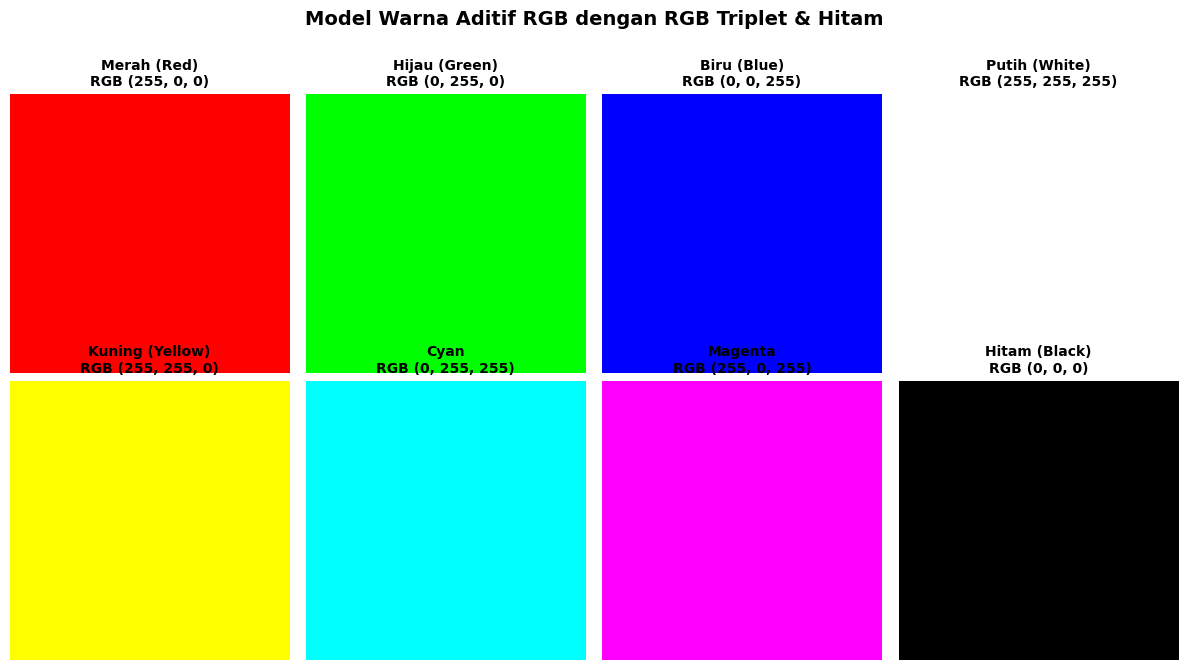

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 01: Menjelaskan model warna aditif RGB dalam citra digital
# Praktikum Pengolahan Citra Ir. Prayitno, S.ST., M.T., Ph.D.

# --- 1. INISIALISASI KANAL WARNA MURNI ---
# Membuat canvas kosong (hitam) berukuran 100x100 dengan 3 kanal (RGB)
red_channel   = np.zeros((100, 100, 3), dtype=np.uint8)
green_channel = np.zeros((100, 100, 3), dtype=np.uint8)
blue_channel  = np.zeros((100, 100, 3), dtype=np.uint8)

# Mengatur nilai intensitas maksimum (255) pada kanal yang sesuai
red_channel[:, :, 0]   = 255  # (255, 0, 0) - Merah
green_channel[:, :, 1] = 255  # (0, 255, 0) - Hijau
blue_channel[:, :, 2]  = 255  # (0, 0, 255) - Biru

# --- 2. KOMBINASI WARNA (MODEL ADITIF) ---
yellow  = red_channel + green_channel            # (255, 255, 0)   - Kuning
cyan    = green_channel + blue_channel           # (0, 255, 255)   - Cyan
magenta = red_channel + blue_channel             # (255, 0, 255)   - Magenta
white   = red_channel + green_channel + blue_channel  # (255, 255, 255) - Putih
black   = np.zeros((100, 100, 3), dtype=np.uint8)      # (0, 0, 0)       - Hitam

# --- 3. PERSIAPAN VISUALISASI ---
fig, axes = plt.subplots(2, 4, figsize=(12, 7))

# Data pendukung untuk iterasi plot
color_list = [
    red_channel, green_channel, blue_channel, white,
    yellow, cyan, magenta, black
]

color_names = [
    "Merah (Red)", "Hijau (Green)", "Biru (Blue)", "Putih (White)",
    "Kuning (Yellow)", "Cyan", "Magenta", "Hitam (Black)"
]

rgb_values = [
    "(255, 0, 0)", "(0, 255, 0)", "(0, 0, 255)", "(255, 255, 255)",
    "(255, 255, 0)", "(0, 255, 255)", "(255, 0, 255)", "(0, 0, 0)"
]

# --- 4. RENDERING PLOT ---
for ax, color, name, rgb in zip(axes.flat, color_list, color_names, rgb_values):
    ax.imshow(color)
    ax.set_title(f"{name}\nRGB {rgb}", fontsize=10, fontweight="bold")
    ax.axis('off')

plt.suptitle("Model Warna Aditif RGB dengan RGB Triplet & Hitam", fontsize=14, fontweight="bold")
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Memberi ruang untuk suptitle
plt.show()

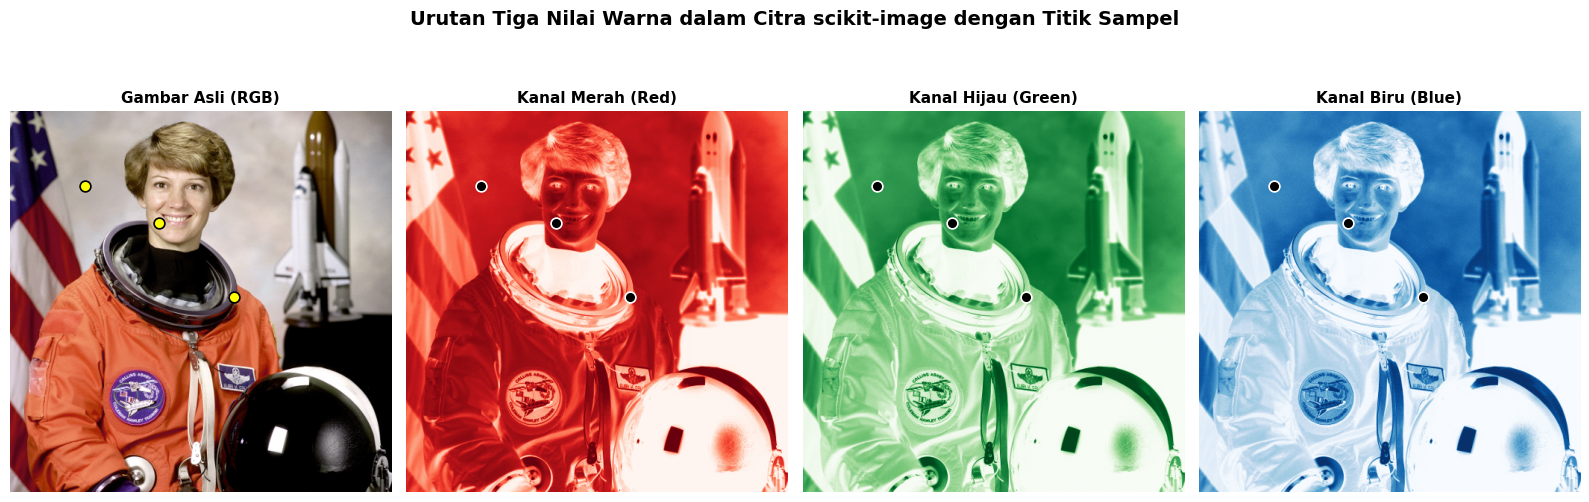

---------------------------------------------
Nilai RGB pada titik koordinat yang dipilih:
---------------------------------------------
Titik 1 - Koordinat (100, 100):
  > Red (Merah)   : 187
  > Green (Hijau) : 176
  > Blue (Biru)   : 169
  > RGB Triplet   : (187, 176, 169)
------------------------------
Titik 2 - Koordinat (200, 150):
  > Red (Merah)   : 236
  > Green (Hijau) : 210
  > Blue (Biru)   : 184
  > RGB Triplet   : (236, 210, 184)
------------------------------
Titik 3 - Koordinat (300, 250):
  > Red (Merah)   : 96
  > Green (Hijau) : 76
  > Blue (Biru)   : 93
  > RGB Triplet   : (96, 76, 93)
------------------------------


In [ ]:
import matplotlib.pyplot as plt
from skimage import data

# 01: Menjelaskan urutan tiga nilai warna dalam citra scikit-image
# 25: Praktikum Pengolahan Citra Ir. Prayitno, S.ST., M.T., Ph.D.

# --- 1. PERSIAPAN DATA ---
# Memuat gambar RGB dari scikit-image
gambar_rgb = data.astronaut()

# Ekstrak tiga kanal warna (R, G, B) menggunakan slicing array NumPy
red_channel   = gambar_rgb[:, :, 0] # Kanal merah
green_channel = gambar_rgb[:, :, 1] # Kanal hijau
blue_channel  = gambar_rgb[:, :, 2] # Kanal biru

# Koordinat tiga titik sampel (x, y) untuk menampilkan nilai piksel RGB
titik_koordinat = [(100, 100), (200, 150), (300, 250)]

# --- 2. VISUALISASI KANAL WARNA ---
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

# Konfigurasi tampilan untuk setiap kanal
titles = ["Gambar Asli (RGB)", "Kanal Merah (Red)", "Kanal Hijau (Green)", "Kanal Biru (Blue)"]
data_plots = [gambar_rgb, red_channel, green_channel, blue_channel]
cmaps = [None, "Reds", "Greens", "Blues"]

for i, ax in enumerate(axes):
    ax.imshow(data_plots[i], cmap=cmaps[i])
    ax.set_title(titles[i], fontsize=11, fontweight="bold")
    ax.axis("off")

    # Tambahkan titik penanda pada setiap plot
    for x, y in titik_koordinat:
        # Warna titik kuning untuk RGB asli, hitam dengan outline putih untuk kanal tunggal
        color_marker = 'yellow' if i == 0 else 'black'
        edge_marker  = 'black' if i == 0 else 'white'
        ax.scatter(x, y, color=color_marker, s=60, edgecolors=edge_marker, linewidth=1.2, zorder=5)

plt.suptitle("Urutan Tiga Nilai Warna dalam Citra scikit-image dengan Titik Sampel",
             fontsize=14, fontweight="bold", y=1.05)
plt.tight_layout()
plt.show()

# --- 3. OUTPUT NILAI PIKSEL ---
print("-" * 45)
print("Nilai RGB pada titik koordinat yang dipilih:")
print("-" * 45)

for i, (x, y) in enumerate(titik_koordinat):
    # Mengambil nilai dari array [y, x, kanal]
    r_val = gambar_rgb[y, x, 0]
    g_val = gambar_rgb[y, x, 1]
    b_val = gambar_rgb[y, x, 2]

    print(f"Titik {i+1} - Koordinat ({x}, {y}):")
    print(f"  > Red (Merah)   : {r_val}")
    print(f"  > Green (Hijau) : {g_val}")
    print(f"  > Blue (Biru)   : {b_val}")
    print(f"  > RGB Triplet   : ({r_val}, {g_val}, {b_val})")
    print("-" * 30)

/tmp/ipykernel_8270/628577188.py:13: FutureWarning: The plugin infrastructure in `skimage.io` is deprecated since version 0.25 and will be removed in 0.27 (or later). To avoid this warning, please do not pass additional keyword arguments for plugins (`**plugin_args`). Instead, use `imageio` or other I/O packages directly. See also `skimage.io.imsave`.
  io.imsave("astronaut.jpg", gambar, quality=95)  # JPEG dengan kompresi lossy


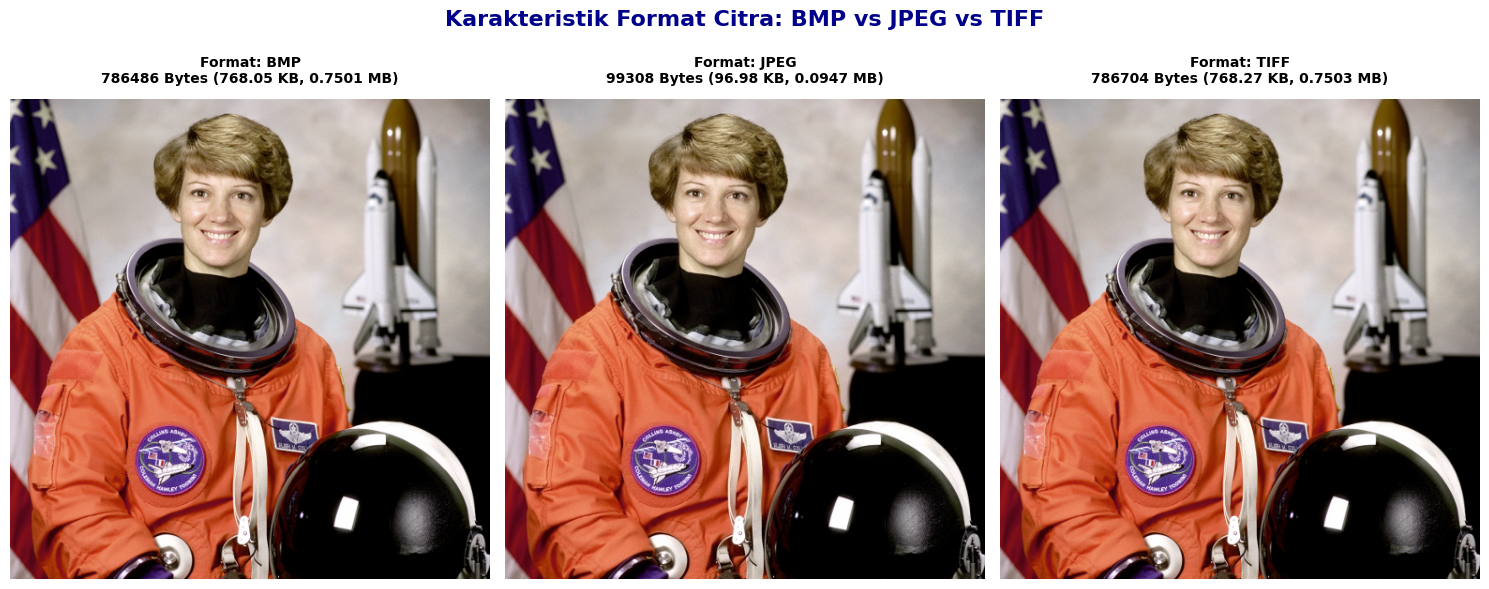

ANALISIS KARAKTERISTIK FORMAT CITRA

1. BMP (Bitmap):
   - Format tidak terkompresi, menghasilkan ukuran file yang besar.
   - Kualitas gambar sangat baik, tidak ada kehilangan data (lossless).
   - Cocok untuk pengolahan citra yang memerlukan ketelitian tinggi.
   >> Ukuran File: 786486 Bytes (768.05 KB, 0.7501 MB)

2. JPEG (Joint Photographic Experts Group):
   - Format terkompresi dengan metode lossy (menghilangkan sebagian data).
   - Ukuran file jauh lebih kecil dibanding BMP dan TIFF.
   - Cocok untuk fotografi, media sosial, dan tampilan web.
   >> Ukuran File: 99308 Bytes (96.98 KB, 0.0947 MB)

3. TIFF (Tagged Image File Format):
   - Format fleksibel yang mendukung kompresi lossy atau lossless.
   - Standar dalam industri percetakan profesional dan medis.
   - Ukuran file cenderung besar tergantung pada metadata yang disimpan.
   >> Ukuran File: 786704 Bytes (768.27 KB, 0.7503 MB)



In [ ]:
import os
import matplotlib.pyplot as plt
from skimage import data, io

# 01: Menjelaskan perbandingan format citra (BMP, JPEG, TIFF)
# 48: Praktikum Pengolahan Citra Ir. Prayitno, S.ST., M.T., Ph.D.

# --- 1. PERSIAPAN DATA & PENYIMPANAN ---
gambar = data.astronaut()

# Simpan gambar dalam berbagai format untuk perbandingan ukuran
io.imsave("astronaut.bmp", gambar)
io.imsave("astronaut.jpg", gambar, quality=95)  # JPEG dengan kompresi lossy
io.imsave("astronaut.tiff", gambar)

# --- 2. FUNGSI UTILITAS ---
def get_ukuran_file(nama_file):
    """Menghitung dan memformat ukuran file ke dalam Bytes, KB, dan MB."""
    size_bytes = os.path.getsize(nama_file)
    size_kb = size_bytes / 1024
    size_mb = size_kb / 1024
    return f"{size_bytes} Bytes ({size_kb:.2f} KB, {size_mb:.4f} MB)"

# --- 3. ANALISIS UKURAN ---
format_citra = ["BMP", "JPEG", "TIFF"]
daftar_file  = ["astronaut.bmp", "astronaut.jpg", "astronaut.tiff"]
info_ukuran  = [get_ukuran_file(f) for f in daftar_file]

# --- 4. VISUALISASI PERBANDINGAN ---
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

for ax, fmt, file in zip(axes, format_citra, daftar_file):
    img = io.imread(file)
    ax.imshow(img)
    # Menampilkan format dan ukuran pada judul tiap subplot
    ax.set_title(f"Format: {fmt}\n{get_ukuran_file(file)}",
                 fontsize=10, fontweight="bold", pad=12)
    ax.axis("off")

plt.suptitle("Karakteristik Format Citra: BMP vs JPEG vs TIFF",
             fontsize=16, fontweight="bold", color="darkblue", y=1.02)
plt.tight_layout()
plt.show()

# --- 5. LAPORAN KARAKTERISTIK ---
print("="*60)
print("ANALISIS KARAKTERISTIK FORMAT CITRA")
print("="*60)

# Data deskripsi format
deskripsi = [
    ("BMP (Bitmap)", [
        "Format tidak terkompresi, menghasilkan ukuran file yang besar.",
        "Kualitas gambar sangat baik, tidak ada kehilangan data (lossless).",
        "Cocok untuk pengolahan citra yang memerlukan ketelitian tinggi."
    ]),
    ("JPEG (Joint Photographic Experts Group)", [
        "Format terkompresi dengan metode lossy (menghilangkan sebagian data).",
        "Ukuran file jauh lebih kecil dibanding BMP dan TIFF.",
        "Cocok untuk fotografi, media sosial, dan tampilan web."
    ]),
    ("TIFF (Tagged Image File Format)", [
        "Format fleksibel yang mendukung kompresi lossy atau lossless.",
        "Standar dalam industri percetakan profesional dan medis.",
        "Ukuran file cenderung besar tergantung pada metadata yang disimpan."
    ])
]

for i, (judul, poin) in enumerate(deskripsi):
    print(f"\n{i+1}. {judul}:")
    for p in poin:
        print(f"   - {p}")
    print(f"   >> Ukuran File: {info_ukuran[i]}")

print("\n" + "="*60)

/tmp/ipykernel_8270/1057663983.py:18: FutureWarning: The plugin infrastructure in `skimage.io` is deprecated since version 0.25 and will be removed in 0.27 (or later). To avoid this warning, please do not pass additional keyword arguments for plugins (`**plugin_args`). Instead, use `imageio` or other I/O packages directly. See also `skimage.io.imsave`.
  io.imsave(file_lossy_50, gambar, quality=50)    # JPEG Quality rendah
/tmp/ipykernel_8270/1057663983.py:19: FutureWarning: The plugin infrastructure in `skimage.io` is deprecated since version 0.25 and will be removed in 0.27 (or later). To avoid this warning, please do not pass additional keyword arguments for plugins (`**plugin_args`). Instead, use `imageio` or other I/O packages directly. See also `skimage.io.imsave`.
  io.imsave(file_lossy_90, gambar, quality=90)    # JPEG Quality tinggi


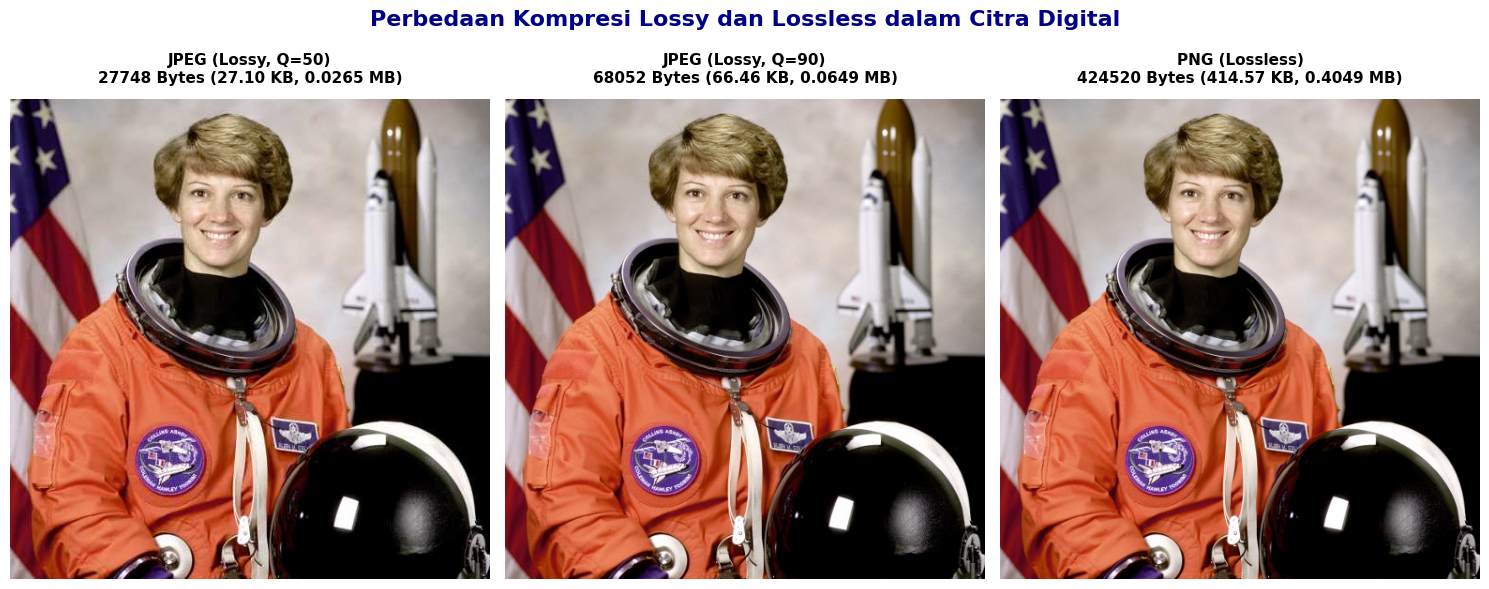

ANALISIS PERBEDAAN KOMPRESI

> JPEG (Lossy, Q=50):
  - Menggunakan kompresi lossy dengan kualitas rendah (Q=50).
  - Detail gambar berkurang, muncul artefak kompresi (blok-blok piksel).
  - Ukuran file paling kecil dibandingkan yang lain.
  * Ukuran file: 27748 Bytes (27.10 KB, 0.0265 MB)

> JPEG (Lossy, Q=90):
  - Menggunakan kompresi lossy dengan kualitas lebih tinggi (Q=90).
  - Detail gambar masih cukup baik, artefak lebih sedikit.
  - Ukuran file moderat (di antara Q=50 dan Lossless).
  * Ukuran file: 68052 Bytes (66.46 KB, 0.0649 MB)

> PNG (Lossless):
  - Menggunakan kompresi lossless, tidak ada data piksel yang dibuang.
  - Detail gambar tetap sempurna (identik dengan file asli).
  - Ukuran file cenderung paling besar karena mempertahankan semua data.
  * Ukuran file: 424520 Bytes (414.57 KB, 0.4049 MB)



In [ ]:
import matplotlib.pyplot as plt
from skimage import io, data
import os

# 01: Menjelaskan perbedaan kompresi lossy dan lossless dalam citra digital
# 12: Praktikum Pengolahan Citra Ir. Prayitno, S.ST., M.T., Ph.D.

# --- 1. PROSES PENYIMPANAN (KOMPRESI) ---
# Memastikan variabel 'gambar' tersedia (menggunakan astronaut dari skimage)
gambar = data.astronaut()

# Nama file untuk berbagai skema kompresi
file_lossy_50    = "astronaut_lossy_50.jpg"
file_lossy_90    = "astronaut_lossy_90.jpg"
file_lossless_png = "astronaut_lossless.png"

# Melakukan kompresi dengan parameter yang berbeda
io.imsave(file_lossy_50, gambar, quality=50)    # JPEG Quality rendah
io.imsave(file_lossy_90, gambar, quality=90)    # JPEG Quality tinggi
io.imsave(file_lossless_png, gambar)            # PNG (Lossless secara default)

# --- FUNGSI UTILITAS ---
def ukuran_file(nama_file):
    """Menghitung dan memformat ukuran file ke dalam Bytes, KB, dan MB."""
    size_bytes = os.path.getsize(nama_file)
    size_kb = size_bytes / 1024
    size_mb = size_kb / 1024
    return f"{size_bytes} Bytes ({size_kb:.2f} KB, {size_mb:.4f} MB)"

# --- 2. ANALISIS UKURAN FILE ---
nama_files = [file_lossy_50, file_lossy_90, file_lossless_png]
labels     = ["JPEG (Lossy, Q=50)", "JPEG (Lossy, Q=90)", "PNG (Lossless)"]

# Asumsi fungsi ukuran_file(file) sudah didefinisikan sebelumnya
info_ukuran = [ukuran_file(f) for f in nama_files]

# --- 3. VISUALISASI PERBANDINGAN ---
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

for ax, file, label in zip(axes, nama_files, labels):
    img = io.imread(file)
    ax.imshow(img)
    ax.set_title(f"{label}\n{ukuran_file(file)}",
                 fontsize=11, fontweight="bold", pad=12)
    ax.axis("off")

plt.suptitle("Perbedaan Kompresi Lossy dan Lossless dalam Citra Digital",
             fontsize=16, fontweight="bold", color="darkblue", y=1.02)
plt.tight_layout()
plt.show()

# --- 4. LAPORAN TEKSTUAL ---
print("="*60)
print("ANALISIS PERBEDAAN KOMPRESI")
print("="*60)

# List data untuk looping print agar lebih rapi
data_laporan = [
    (labels[0], [
        "Menggunakan kompresi lossy dengan kualitas rendah (Q=50).",
        "Detail gambar berkurang, muncul artefak kompresi (blok-blok piksel).",
        "Ukuran file paling kecil dibandingkan yang lain."
    ], info_ukuran[0]),
    (labels[1], [
        "Menggunakan kompresi lossy dengan kualitas lebih tinggi (Q=90).",
        "Detail gambar masih cukup baik, artefak lebih sedikit.",
        "Ukuran file moderat (di antara Q=50 dan Lossless)."
    ], info_ukuran[1]),
    (labels[2], [
        "Menggunakan kompresi lossless, tidak ada data piksel yang dibuang.",
        "Detail gambar tetap sempurna (identik dengan file asli).",
        "Ukuran file cenderung paling besar karena mempertahankan semua data."
    ], info_ukuran[2])
]

for judul, poin, size in data_laporan:
    print(f"\n> {judul}:")
    for p in poin:
        print(f"  - {p}")
    print(f"  * Ukuran file: {size}")

print("\n" + "="*60)